Detected bin width: 10.000 µs
Total number of bins: 1000
g²(0) = 2.517
g²(∞) ≈ 3.172
Contrast = g²(0) / g²(∞) ≈ 0.794


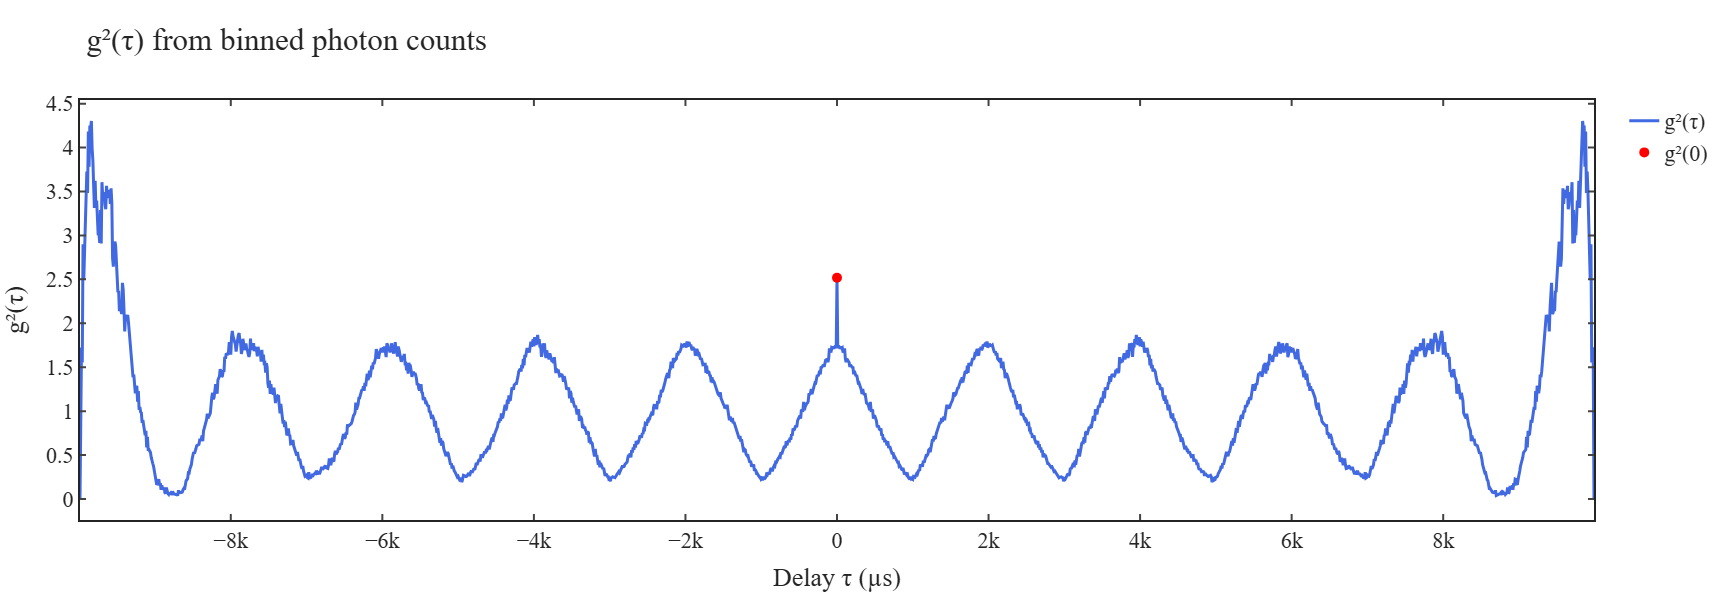

Plot saved to: D:\Data\2025\August\21 Aug Tm UCP spectra dual beam Agniva\Bi UCP Red emission\g2 measurement\g2_plot_10.000us_1000bins.html


In [68]:
import numpy as np
import plotly.graph_objects as go

# --------------------------
# Load data: time and counts
# --------------------------
data = np.loadtxt(
    r"D:\Data\2025\August\21 Aug Tm UCP spectra dual beam Agniva\Bi UCP Red emission\g2 measurement\10us_1000bins.txt",
    skiprows=1
)
times_ps = data[:, 0]   # time in picoseconds
counts = data[:, 1]     # photon counts

# --------------------------
# Calculate bin width and total bins
# --------------------------
bin_width_ps = np.mean(np.diff(times_ps))  # ps
bin_width_us = bin_width_ps / 1e6          # convert to µs
N = len(counts)

print(f"Detected bin width: {bin_width_us:.3f} µs")
print(f"Total number of bins: {N}")

# --------------------------
# Compute full g²(τ) function
# --------------------------
def g2_full_autocorrelation(counts):
    mean_count = np.mean(counts)
    raw_corr = np.correlate(counts, counts, mode='full')  # length 2N-1
    g2 = raw_corr / (mean_count**2)

    # Overlap normalization for unbiased estimate
    lags = np.arange(-N + 1, N)
    norm = N - np.abs(lags)
    g2 /= norm

    return lags, g2

lags, g2 = g2_full_autocorrelation(counts)

# --------------------------
# Create τ axis in µs
# --------------------------
taus = lags * bin_width_us  # τ axis in microseconds

# --------------------------
# Compute and display g²(0), g²(∞), contrast
# --------------------------
zero_index = np.where(lags == 0)[0][0]
g2_0 = g2[zero_index]
g2_inf = np.mean(np.concatenate([g2[:50], g2[-50:]]))  # average far from center
contrast = g2_0 / g2_inf

print(f"g²(0) = {g2_0:.3f}")
print(f"g²(∞) ≈ {g2_inf:.3f}")
print(f"Contrast = g²(0) / g²(∞) ≈ {contrast:.3f}")

# --------------------------
# Plot using Plotly with custom template
# --------------------------
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'title': 'Delay τ (µs)',
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'title': 'g²(τ)',
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

fig = go.Figure(layout=fig_template.layout)

# g²(τ) trace
fig.add_trace(go.Scatter(
    x=taus, y=g2,
    mode='lines',
    name='g²(τ)',
    line=dict(color='royalblue', width=3)
))

# Marker at τ = 0
fig.add_trace(go.Scatter(
    x=[0],
    y=[g2_0],
    mode='markers',
    marker=dict(color='red', size=10, symbol='circle'),
    name='g²(0)'
))

# Update layout
fig.update_layout(title="g²(τ) from binned photon counts")
fig.show()

# --------------------------
# Save the plot as HTML
# --------------------------
import os

# Build filename with bin width and number of bins
filename = f"g2_plot_{bin_width_us:.3f}us_{N}bins.html"

# Define output folder (optional: you can change this)
output_folder = r"D:\Data\2025\August\21 Aug Tm UCP spectra dual beam Agniva\Bi UCP Red emission\g2 measurement"
output_path = os.path.join(output_folder, filename)

# Save figure
fig.write_html(output_path)
print(f"Plot saved to: {output_path}")